In [1]:
from typing import TypedDict, Literal
class PortfolioState(TypedDict):
    amt_usd: float
    total_usd: float
    target_currency: Literal['USD', 'INR']
    total_inr: float

In [6]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state["total_usd"] = state["amt_usd"]
    return state

def convert_to_eur(state: PortfolioState) -> PortfolioState:
    state["total_usd"] = state["amt_usd"] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state["total_inr"] = state["amt_usd"] * 75
    return state

def choose_currency(state: PortfolioState) -> Literal["USD", "INR"]:
    return state["target_currency"]


In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("calc_total", calc_total)
builder.add_node("convert_to_inr", convert_to_inr)
builder.add_node("convert_to_eur", convert_to_eur)
builder.add_node("choose_currency", choose_currency)


builder.add_edge(START, "calc_total")
builder.add_conditional_edges("calc_total", choose_currency, {
    "USD": "convert_to_eur",
    "INR": "convert_to_inr"})

builder.add_edge("convert_to_eur", END)
builder.add_edge("convert_to_inr", END)

graph = builder.compile()


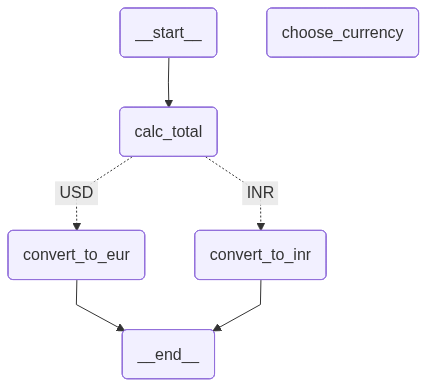

In [8]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"amt_usd": 100, "target_currency": "USD"})

{'amt_usd': 100, 'total_usd': 108.0, 'target_currency': 'USD'}